<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/Section_5_Working_with_Time_Series_in_Python_Completed_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Relevant Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()

### Loading and Transforming the Data

In [2]:
raw_csv_data = pd.read_csv("/content/sample_data/Index2018.csv") #read directly from Pandas library
df_comp = raw_csv_data.copy() #df_comp --> complete DataFrame

df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.fillna(method='ffill')

/tmp/ipython-input-1923774798.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_comp=df_comp.fillna(method='ffill')




### Removing Surplus Data

In [3]:
df_comp['market_value']=df_comp.spx

In [4]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [5]:
df_comp.describe()

,market_value
count,6277.000000
mean,1288.642547
std,487.868210
min,438.920000
25%,992.715221
50%,1233.761241
75%,1460.250000
max,2872.867839


 White noise - no patterm,

 we cannot preduict white noise

### White Noise

In [6]:
wn = np.random.normal(loc = df.market_value.mean(), scale = df.market_value.std(), size = len(df)) #generation of white noise

In [7]:
df['wn'] = wn

/tmp/ipython-input-672873062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wn'] = wn


In [8]:
df.describe()

,market_value,wn
count,5021.000000,5021.000000
mean,1091.651926,1085.767430
std,292.559287,291.985679
min,438.920000,-21.245690
25%,914.620000,893.854623
50%,1144.650000,1089.870968
75%,1316.280729,1285.041329
max,1570.252238,2051.308645


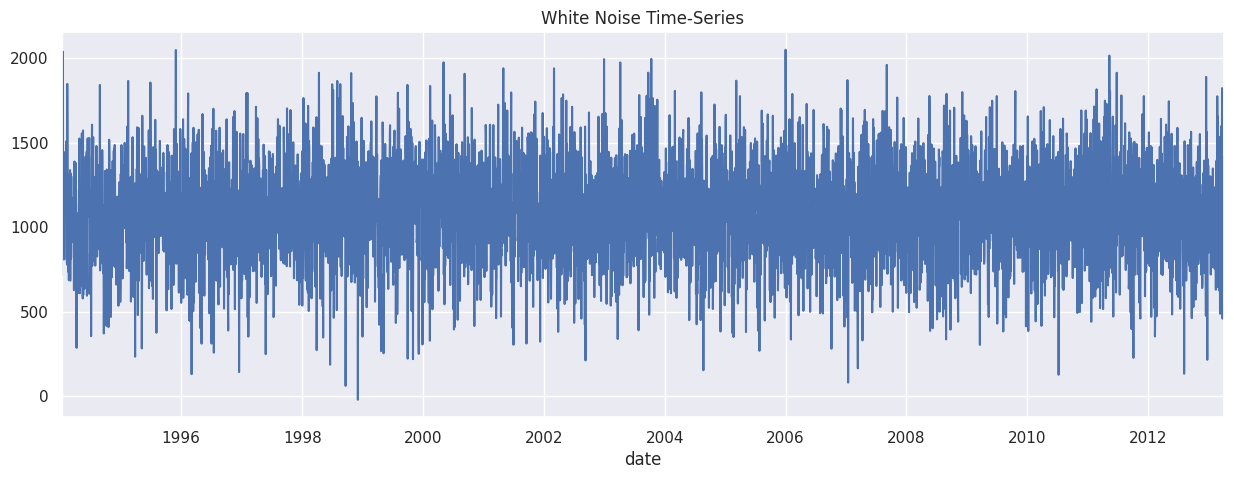

In [9]:
df.wn.plot(figsize = (15,5))
plt.title("White Noise Time-Series", size= 12)
plt.show()

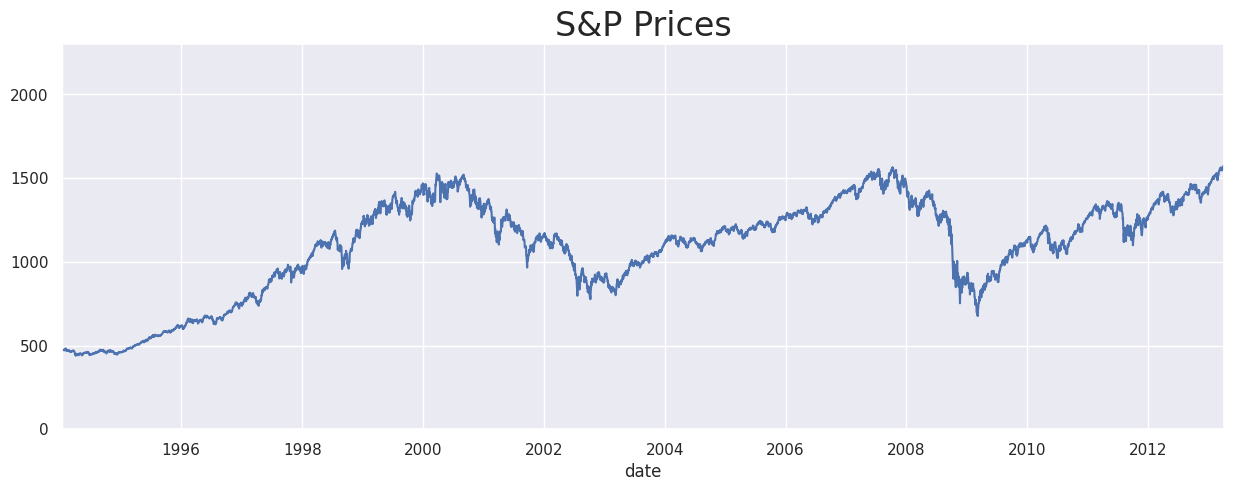

In [10]:
df.market_value.plot(figsize=(15,5))
plt.title("S&P Prices", size = 24)
plt.ylim(0,2300)
plt.show()

### Random Walk

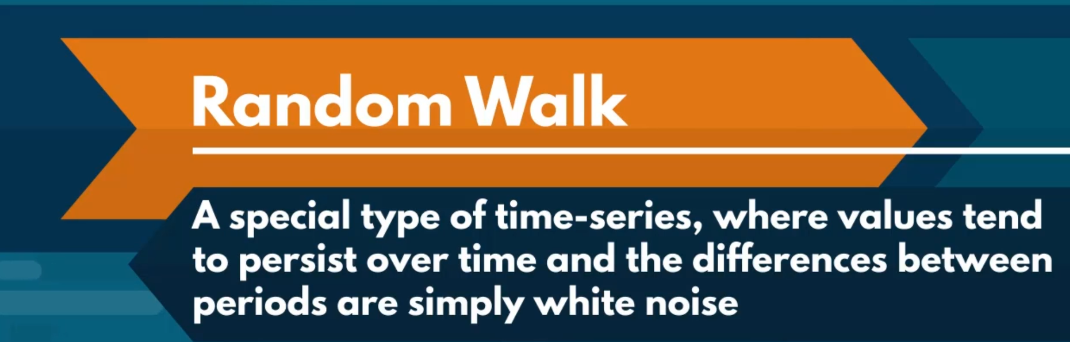

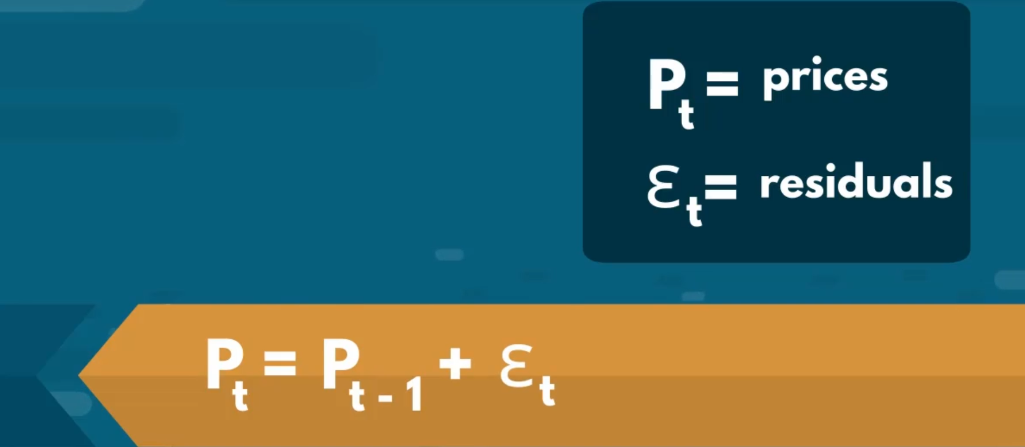

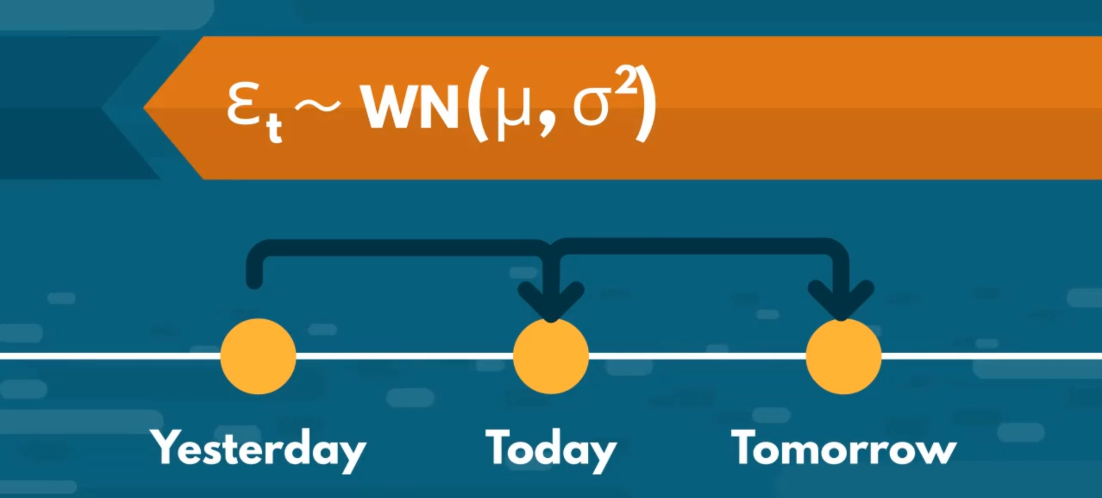

Persystentny

In [11]:
rw = pd.read_csv("/content/sample_data/RandWalk.csv")
rw.date = pd.to_datetime(rw.date, dayfirst=True)  # convert 'date' column to datetime; interpret dates as day-month-year (DD/MM/YY) first
rw.set_index("date", inplace=True)                # set 'date' as the DataFrame index (modifies rw in place)
rw = rw.asfreq("B")                               # enforce business-day frequency (Mon–Fri); missing business days become NaN


In [12]:
rw.describe()

,price
count,5021.000000
mean,1269.944293
std,444.216793
min,585.483034
25%,931.550429
50%,1156.363045
75%,1488.362029
max,2715.508720


In [13]:
rw.head()

,price
date,
1994-01-07,1122.139662
1994-01-10,1080.347860
1994-01-11,1082.095245
1994-01-12,1083.639265
1994-01-13,1067.146255


In [14]:
df.head()

,market_value,wn
date,,
1994-01-07,469.90,1321.093437
1994-01-10,475.27,714.625786
1994-01-11,474.13,1138.453448
1994-01-12,474.17,1154.619768
1994-01-13,472.47,1335.254411


In [15]:
df['rw'] = rw.price #add kolumn rw to df - rememeber df is training data

/tmp/ipython-input-3124744209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rw'] = rw.price #add kolumn rw to df - rememeber df is training data


In [16]:
df.head()

,market_value,wn,rw
date,,,
1994-01-07,469.90,1321.093437,1122.139662
1994-01-10,475.27,714.625786,1080.347860
1994-01-11,474.13,1138.453448,1082.095245
1994-01-12,474.17,1154.619768,1083.639265
1994-01-13,472.47,1335.254411,1067.146255


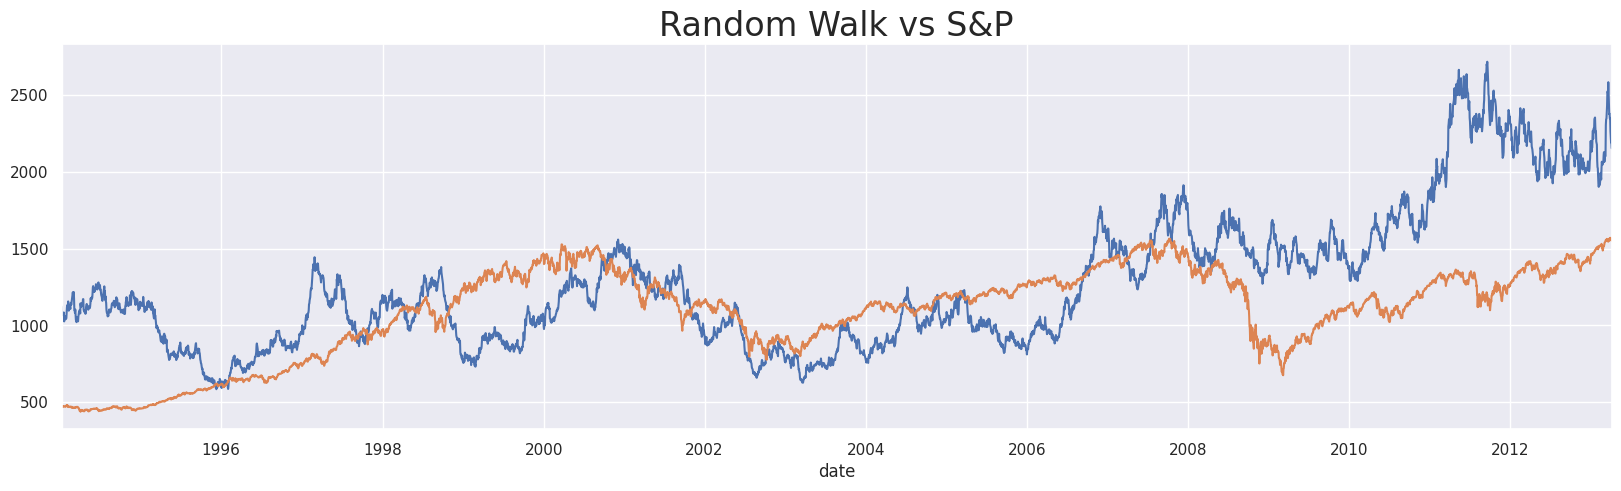

In [20]:
df.rw.plot(figsize = (20,5))
df.market_value.plot()
#df.wn.plot()
plt.title("Random Walk vs S&P", size = 24)
plt.show()

### Stationarity

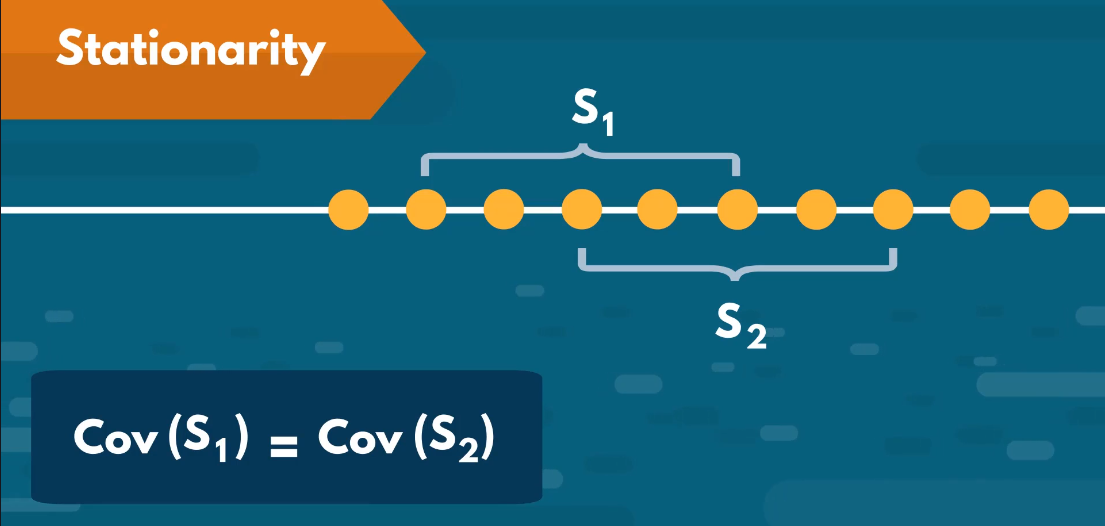

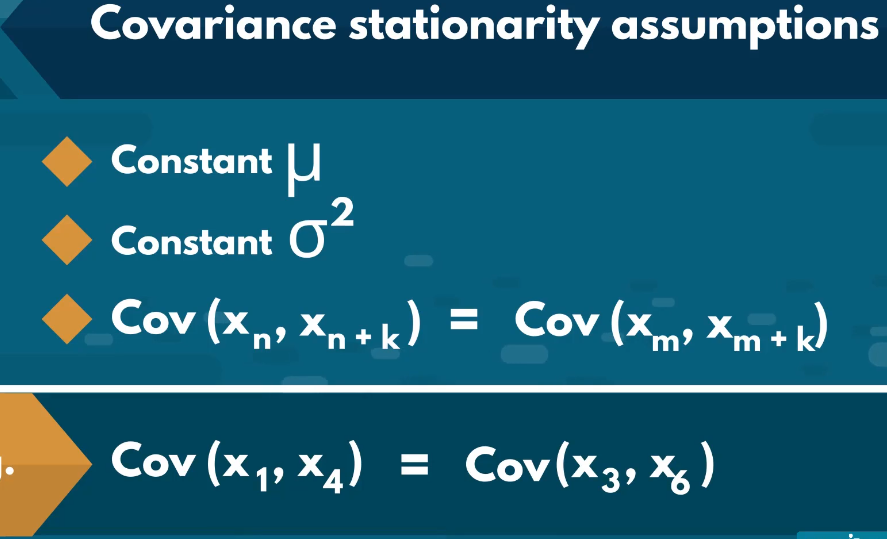

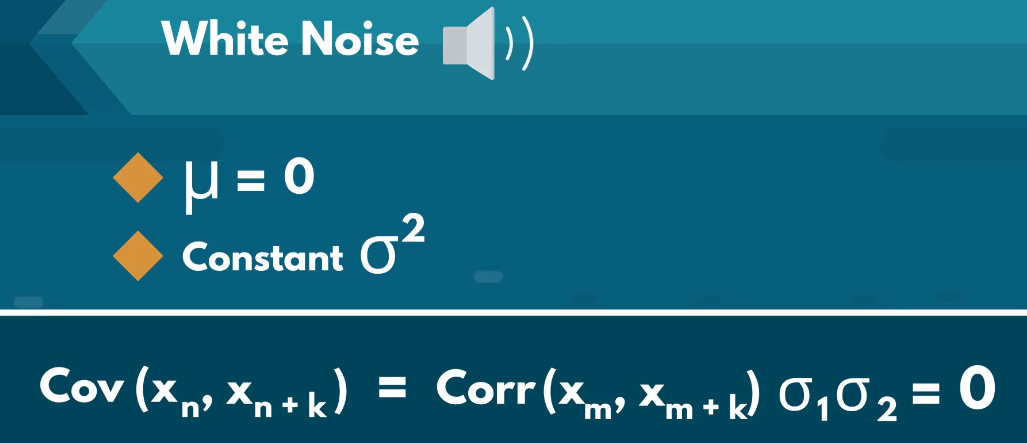

μ = 0
Średnia sygnału = 0. Czyli szum “kręci się” wokół zera, bez trendu.

Constant σ²
Wariancja jest stała w czasie (stała „moc” szumu). Brak zmiany rozrzutu.

Cov(xₙ, xₙ₊ₖ) = 0 dla k ≠ 0
Próbki w różnych chwilach są nieskorelowane: wartość teraz nie mówi nic o wartości za
𝑘
k kroków.
Innymi słowy: brak pamięci.
Szum biały ma kowariancję, autokorelację = 0


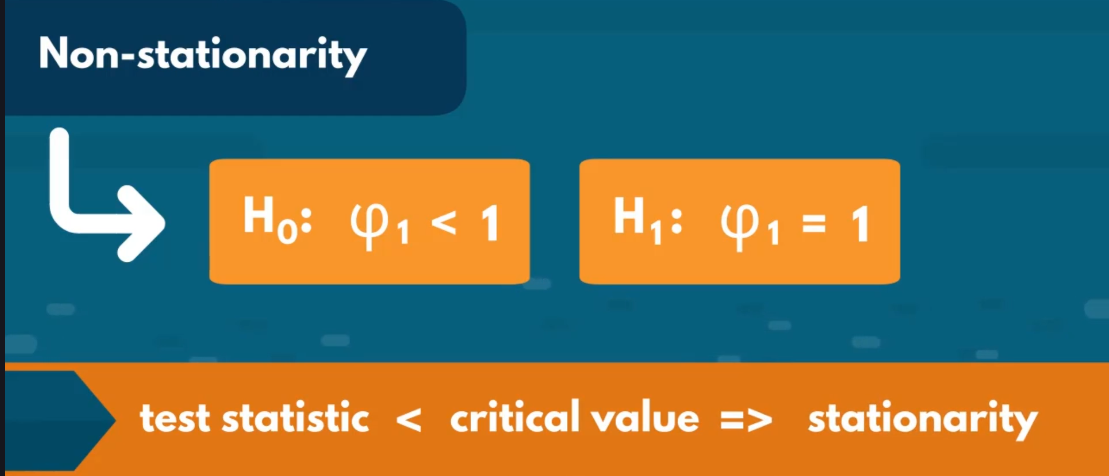

ADF (test statistic < critical value (5%)) => STATIONARY

ADF (test statistic > critical value (5%)) => NON STATIONARY

p value < 0,05 => STATIONARY (H0 is NOK)

p value > 0,05 => NON STATIONARY (H0 is ok)


In [27]:
sts.adfuller(df.market_value)

(np.float64(-1.7369847452352447),
 np.float64(0.4121645696770616),
 18,
 5002,
 {'1%': np.float64(-3.431658008603046),
  '5%': np.float64(-2.862117998412982),
  '10%': np.float64(-2.567077669247375)},
 np.float64(39904.880607487445))

In [28]:
import statsmodels.tsa.stattools as sts  # ADF test lives here

# --- run ADF test (drop NaNs because ADF hates missing values) ---
series = df["market_value"].dropna()                 # clean series (no NaNs)
adf_out = sts.adfuller(series, autolag="AIC")        # ADF test + automatic lag selection by AIC

# --- unpack results ---
adf_stat = adf_out[0]                                # test statistic
p_value = adf_out[1]                                 # p-value
used_lags = adf_out[2]                               # number of lags used
n_obs = adf_out[3]                                   # number of observations used
crit = adf_out[4]                                    # critical values dict: 1%, 5%, 10%
icbest = adf_out[5]                                  # best information criterion value (from autolag)

# --- print raw results ---
print(f"ADF statistic: {adf_stat:.6f}")              # more negative -> stronger evidence vs unit root
print(f"p-value:       {p_value:.6g}")               # key decision number
print(f"used lags:     {used_lags}")                 # how many lagged differences included
print(f"n obs:         {n_obs}")                     # effective sample size
print("critical values:", crit)                      # thresholds for 1%, 5%, 10%
print(f"IC best:       {icbest:.6f}")                # chosen by autolag criterion

# --- interpret stationarity ---
alpha = 0.05                                         # significance level
if p_value < alpha:
    print(f"Decision @ {alpha}: REJECT H0 (unit root) -> series is likely STATIONARY.")
else:
    print(f"Decision @ {alpha}: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).")

# --- optional: interpretation using critical values (extra sanity check) ---
if adf_stat < crit["5%"]:
    print("Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.")
else:
    print("Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.")


ADF statistic: -1.736985
p-value:       0.412165
used lags:     18
n obs:         5002
critical values: {'1%': np.float64(-3.431658008603046), '5%': np.float64(-2.862117998412982), '10%': np.float64(-2.567077669247375)}
IC best:       39904.880607
Decision @ 0.05: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).
Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.


In [29]:
sts.adfuller(df.wn)

(np.float64(-71.05499960978636),
 0.0,
 0,
 5020,
 {'1%': np.float64(-3.431653316130827),
  '5%': np.float64(-2.8621159253018247),
  '10%': np.float64(-2.5670765656497516)},
 np.float64(70784.96083576411))

In [30]:
import statsmodels.tsa.stattools as sts  # ADF test lives here

# --- run ADF test (drop NaNs because ADF hates missing values) ---
series = df["wn"].dropna()                 # clean series (no NaNs)
adf_out = sts.adfuller(series, autolag="AIC")        # ADF test + automatic lag selection by AIC

# --- unpack results ---
adf_stat = adf_out[0]                                # test statistic
p_value = adf_out[1]                                 # p-value
used_lags = adf_out[2]                               # number of lags used
n_obs = adf_out[3]                                   # number of observations used
crit = adf_out[4]                                    # critical values dict: 1%, 5%, 10%
icbest = adf_out[5]                                  # best information criterion value (from autolag)

# --- print raw results ---
print(f"ADF statistic: {adf_stat:.6f}")              # more negative -> stronger evidence vs unit root
print(f"p-value:       {p_value:.6g}")               # key decision number
print(f"used lags:     {used_lags}")                 # how many lagged differences included
print(f"n obs:         {n_obs}")                     # effective sample size
print("critical values:", crit)                      # thresholds for 1%, 5%, 10%
print(f"IC best:       {icbest:.6f}")                # chosen by autolag criterion

# --- interpret stationarity ---
alpha = 0.05                                         # significance level
if p_value < alpha:
    print(f"Decision @ {alpha}: REJECT H0 (unit root) -> series is likely STATIONARY.")
else:
    print(f"Decision @ {alpha}: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).")

# --- optional: interpretation using critical values (extra sanity check) ---
if adf_stat < crit["5%"]:
    print("Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.")
else:
    print("Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.")


ADF statistic: -71.055000
p-value:       0
used lags:     0
n obs:         5020
critical values: {'1%': np.float64(-3.431653316130827), '5%': np.float64(-2.8621159253018247), '10%': np.float64(-2.5670765656497516)}
IC best:       70784.960836
Decision @ 0.05: REJECT H0 (unit root) -> series is likely STATIONARY.
Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.


In [31]:
sts.adfuller(df.rw)

(np.float64(-1.3286073927689712),
 np.float64(0.6159849181617387),
 24,
 4996,
 {'1%': np.float64(-3.4316595802782865),
  '5%': np.float64(-2.8621186927706463),
  '10%': np.float64(-2.567078038881065)},
 np.float64(46299.333497595144))

In [32]:
import statsmodels.tsa.stattools as sts  # ADF test lives here

# --- run ADF test (drop NaNs because ADF hates missing values) ---
series = df["rw"].dropna()                 # clean series (no NaNs)
adf_out = sts.adfuller(series, autolag="AIC")        # ADF test + automatic lag selection by AIC

# --- unpack results ---
adf_stat = adf_out[0]                                # test statistic
p_value = adf_out[1]                                 # p-value
used_lags = adf_out[2]                               # number of lags used
n_obs = adf_out[3]                                   # number of observations used
crit = adf_out[4]                                    # critical values dict: 1%, 5%, 10%
icbest = adf_out[5]                                  # best information criterion value (from autolag)

# --- print raw results ---
print(f"ADF statistic: {adf_stat:.6f}")              # more negative -> stronger evidence vs unit root
print(f"p-value:       {p_value:.6g}")               # key decision number
print(f"used lags:     {used_lags}")                 # how many lagged differences included
print(f"n obs:         {n_obs}")                     # effective sample size
print("critical values:", crit)                      # thresholds for 1%, 5%, 10%
print(f"IC best:       {icbest:.6f}")                # chosen by autolag criterion

# --- interpret stationarity ---
alpha = 0.05                                         # significance level
if p_value < alpha:
    print(f"Decision @ {alpha}: REJECT H0 (unit root) -> series is likely STATIONARY.")
else:
    print(f"Decision @ {alpha}: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).")

# --- optional: interpretation using critical values (extra sanity check) ---
if adf_stat < crit["5%"]:
    print("Sanity check: ADF statistic is below the 5% critical value -> supports stationarity.")
else:
    print("Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.")


ADF statistic: -1.328607
p-value:       0.615985
used lags:     24
n obs:         4996
critical values: {'1%': np.float64(-3.4316595802782865), '5%': np.float64(-2.8621186927706463), '10%': np.float64(-2.567078038881065)}
IC best:       46299.333498
Decision @ 0.05: FAIL TO REJECT H0 -> series is likely NON-STATIONARY (unit root).
Sanity check: ADF statistic is NOT below the 5% critical value -> supports non-stationarity.


### Seasonality

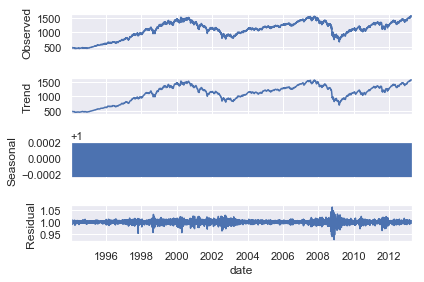

In [ ]:
s_dec_multiplicative = seasonal_decompose(df.market_value, model = "multiplicative")
s_dec_multiplicative.plot()
plt.show()

### ACF

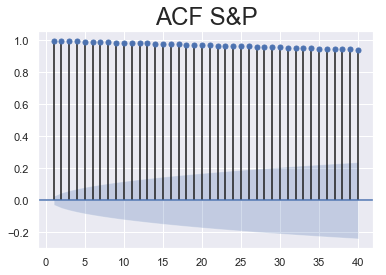

In [ ]:
sgt.plot_acf(df.market_value, lags = 40, zero = False)
plt.title("ACF S&P", size = 24)
plt.show()

### PACF

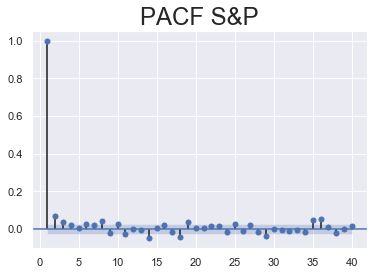

In [ ]:
sgt.plot_pacf(df.market_value, lags = 40, zero = False, method = ('ols'))
plt.title("PACF S&P", size = 24)
plt.show()

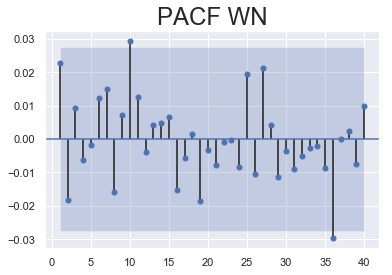

In [ ]:
sgt.plot_pacf(df.wn, lags = 40, zero = False, method = ('ols'))
plt.title("PACF WN", size = 24)
plt.show()